# RF Fingerprinting Notebook

Notebook-first workflow for real vs complex RF encoders with synthetic fallback data.

Modes:
- `fast`: quick smoke tests (small data, short training).
- `base`: balanced default for iteration.
- `full`: longer run for stronger comparison numbers.

In [ ]:
import numpy as np
import torch

from config import load_config, save_scorecard_csv
from data import load_or_generate_npz
from datasets import IQDataset, TwoViewIQDataset, augment_iq, split_indices
from models import ComplexEncoder1D, RealEncoder1D
from training import (
    collect_logits,
    evaluate_logits,
    finetune_classifier,
    open_set_auc,
    pretrain_simclr,
    run_linear_probe,
)
from visualize import plot_history, plot_iq_views

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

MODE = 'full'  # choose from: 'fast', 'base', 'full'
DATASET_PATH = ''  # optional .npz path
OUTPUT_DIR_OVERRIDE = ''  # optional output dir override

cfg = load_config(mode=MODE)
if DATASET_PATH:
    cfg.dataset_path = DATASET_PATH
if OUTPUT_DIR_OVERRIDE:
    cfg.output_dir = OUTPUT_DIR_OVERRIDE

print({
    'mode': cfg.mode,
    'n_samples': cfg.n_samples,
    'batch_size': cfg.batch_size,
    'pretrain_epochs': cfg.pretrain_epochs,
    'finetune_epochs': cfg.finetune_epochs,
    'output_dir': cfg.output_dir,
})
cfg


{'mode': 'fast', 'n_samples': 800, 'batch_size': 64, 'pretrain_epochs': 2, 'finetune_epochs': 5, 'output_dir': '/home/hinson/projects/hinsonan.github.io/code_examples/complex_vs_real_nn/rf_fingerprinting/outputs/rf_fingerprinting_fast'}


RFConfig(mode='fast', dataset_path='', output_dir='/home/hinson/projects/hinsonan.github.io/code_examples/complex_vs_real_nn/rf_fingerprinting/outputs/rf_fingerprinting_fast', seed=7, seq_len=256, n_devices=6, n_sessions=3, n_samples=800, test_size=0.2, val_size=0.2, batch_size=64, embed_dim=64, pretrain_epochs=2, finetune_epochs=5, lr=0.001, weight_decay=0.0001, temperature=0.2, noise_std=0.05, phase_jitter_rad=0.05, time_shift=8, cfo_jitter_rad=0.0, amplitude_jitter=0.05, aug_prob=0.5, grad_clip=0.0, dropout=0.0, encoder_lr_scale=1.0, warmup_epochs=1)

In [3]:
data = load_or_generate_npz(cfg)
print({k: v.shape for k, v in data.items()})
print('num_devices:', int(data['device_id'].max()) + 1)
print('num_sessions:', int(data['session_id'].max()) + 1)

{'iq': (800, 256), 'device_id': (800,), 'session_id': (800,)}
num_devices: 6
num_sessions: 3


In [4]:
splits = split_indices(
    data['iq'].shape[0],
    cfg.test_size,
    cfg.val_size,
    cfg.seed,
    labels=data['device_id'],
)
train_ds = IQDataset(data['iq'][splits['train']], data['device_id'][splits['train']])
val_ds = IQDataset(data['iq'][splits['val']], data['device_id'][splits['val']])
test_ds = IQDataset(data['iq'][splits['test']], data['device_id'][splits['test']])
num_classes = int(data['device_id'].max()) + 1
len(train_ds), len(val_ds), len(test_ds), num_classes

(518, 126, 156, 6)

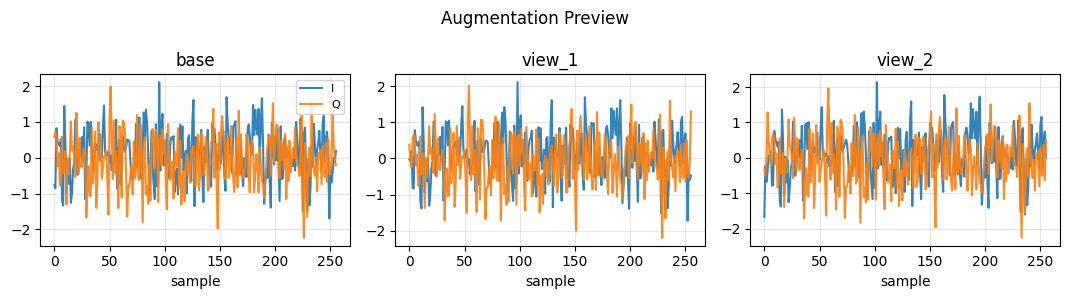

In [5]:
sample = data['iq'][0]
v1 = augment_iq(sample, noise_std=cfg.noise_std, phase_jitter_rad=cfg.phase_jitter_rad, time_shift=cfg.time_shift)
v2 = augment_iq(sample, noise_std=cfg.noise_std, phase_jitter_rad=cfg.phase_jitter_rad, time_shift=cfg.time_shift)
_ = plot_iq_views(sample, [v1, v2], title='Augmentation Preview')


In [6]:
two_view_ds = TwoViewIQDataset(data['iq'][splits['train']], cfg)

def run_pipeline(name):
    if name == 'real':
        encoder = RealEncoder1D(embed_dim=cfg.embed_dim)
    else:
        encoder = ComplexEncoder1D(embed_dim=cfg.embed_dim)

    pre_hist = pretrain_simclr(encoder, two_view_ds, cfg, device)
    probe_metrics = run_linear_probe(encoder.to(device), train_ds, test_ds, device)

    ft_model, ft_hist = finetune_classifier(
        encoder=encoder.to(device),
        train_dataset=train_ds,
        val_dataset=val_ds,
        num_classes=num_classes,
        cfg=cfg,
        device=device,
    )

    test_logits, test_labels = collect_logits(ft_model, test_ds, device)
    eval_metrics = evaluate_logits(test_logits, test_labels)

    ood_logits = test_logits + 0.75 * np.random.randn(*test_logits.shape)
    os_metrics = open_set_auc(test_logits, ood_logits)

    row = {
        'encoder': name,
        'pretrain_final_loss': float(pre_hist['loss'][-1]),
        'probe_acc': float(probe_metrics['probe_acc']),
        'test_acc': float(eval_metrics['acc']),
        'test_f1_macro': float(eval_metrics['f1_macro']),
        'open_set_auroc': float(os_metrics['open_set_auroc']),
    }
    return row, pre_hist, ft_hist

real_row, real_pre_hist, real_ft_hist = run_pipeline('real')
complex_row, complex_pre_hist, complex_ft_hist = run_pipeline('complex')
scorecard = [real_row, complex_row]
scorecard

[{'encoder': 'real',
  'pretrain_final_loss': 3.1467957496643066,
  'probe_acc': 0.8141025641025641,
  'test_acc': 0.6089743589743589,
  'test_f1_macro': 0.550150194758038,
  'open_set_auroc': 0.39907955292570674},
 {'encoder': 'complex',
  'pretrain_final_loss': 2.757215917110443,
  'probe_acc': 0.8846153846153846,
  'test_acc': 0.6025641025641025,
  'test_f1_macro': 0.549793286635392,
  'open_set_auroc': 0.19444444444444445}]

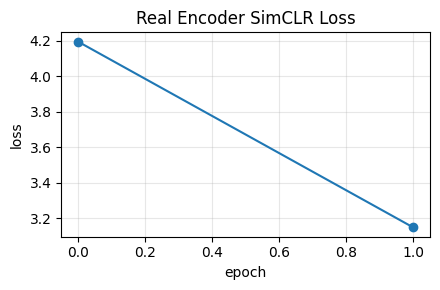

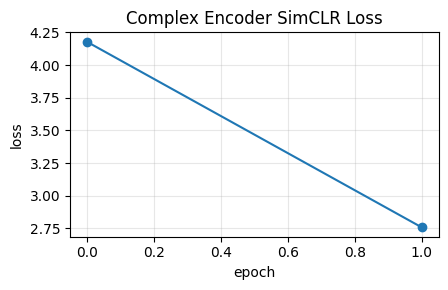

In [7]:
_ = plot_history(real_pre_hist, 'loss', 'Real Encoder SimCLR Loss')
_ = plot_history(complex_pre_hist, 'loss', 'Complex Encoder SimCLR Loss')

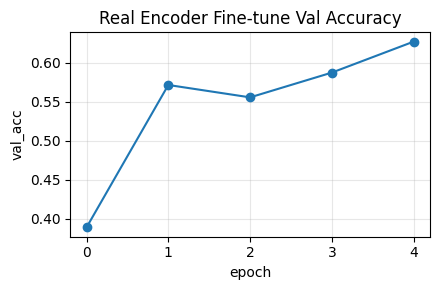

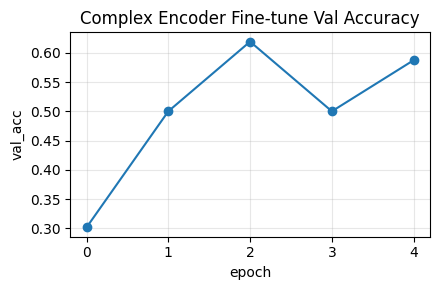

In [8]:
_ = plot_history(real_ft_hist, 'val_acc', 'Real Encoder Fine-tune Val Accuracy')
_ = plot_history(complex_ft_hist, 'val_acc', 'Complex Encoder Fine-tune Val Accuracy')

In [9]:
scorecard_path = f"{cfg.output_dir}/scorecard.csv"
save_scorecard_csv(scorecard_path, scorecard)
print('scorecard_csv:', scorecard_path)
scorecard

scorecard_csv: /home/hinson/projects/hinsonan.github.io/code_examples/complex_vs_real_nn/rf_fingerprinting/outputs/rf_fingerprinting_fast/scorecard.csv


[{'encoder': 'real',
  'pretrain_final_loss': 3.1467957496643066,
  'probe_acc': 0.8141025641025641,
  'test_acc': 0.6089743589743589,
  'test_f1_macro': 0.550150194758038,
  'open_set_auroc': 0.39907955292570674},
 {'encoder': 'complex',
  'pretrain_final_loss': 2.757215917110443,
  'probe_acc': 0.8846153846153846,
  'test_acc': 0.6025641025641025,
  'test_f1_macro': 0.549793286635392,
  'open_set_auroc': 0.19444444444444445}]